# VEP DNA Pipeline

## Install core dependencies

- Each model run in the VEP DNA pipeline requires slightly different dependencies. 
- While `vep_pipeline` can theoretically run multiple models in a single python session, it's more practical to maintain
separate conda environments and activate the model's respective environemnt before running `vep_pipeline` on that model.
- See the folder *conda/* for different conda env yamls for each model. To install, just run conda env `create -f <path/to/file.yml`>.


Nevertheless, here are the core dependencies that the pipeline always needs to run `vep_pipeline` (if the conda yaml does not already install them for you). 

The following examples use only chromosome 22 in the Geuvadis collection from 1000 Genomes Project (452 individals).

In [ ]:
# To install GenVarLoader
!conda install bioconda::pgenlib -y
!pip install git+https://github.com/mcvickerlab/GenVarLoader.git

# To install xarray
!conda install conda-forge::xarray conda-forge::zarr -y

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.utils as utils

# Set environment variable to suppress datetime warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

# Create GVL database

## Download population data

In [91]:
# GRCh38 chromosome 22 sequence
reference = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
)
if not Path(f"{reference[:-3]}.bgz").exists():
    !gzip -dc {reference} | bgzip > {reference[:-3]}.bgz
reference = reference[:-3] + ".bgz"

# PLINK 2 files
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
)

# BED
bed_path = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/chr22_egenes.bed",
    known_hash="md5:ccb55548e4ddd416d50dbe6638459421",
    progressbar=True,
)


## Create BED file

This BED file is based on the coordinates of the UTR variants we're planning on injecting, surrounded by 500kb windows.

In [92]:
bed = gvl.read_bedlike("data/UTR/snps_500kb_windows.bed")[:20]
bed.head()

chrom,chromStart,chromEnd,name,score,strand
str,i64,i64,str,f64,str
"""22""",16835042,17335042,"""340557""",0.0,"""+"""
"""22""",16835050,17335050,"""340558""",0.0,"""+"""
"""22""",16835053,17335053,"""340559""",0.0,"""+"""
"""22""",16835059,17335059,"""894942""",0.0,"""+"""
"""22""",16835065,17335065,"""340560""",0.0,"""+"""


## Create GVL database

In [94]:
tmp_dir = TemporaryDirectory(suffix=".gvl")
ds_path = tmp_dir.name
gvl.write(
    path=ds_path,
    bed=gvl.with_length(bed, 2**18),  # change region length to 131,072 bp
    variants=variants,
    overwrite=True,
)

/home/schilder/.conda/envs/flashzoi/lib/python3.12/tempfile.py:940: ResourceWarning: Implicitly cleaning up <TemporaryDirectory '/tmp/tmpjgcvlvz_.gvl'>
  _warnings.warn(warn_message, ResourceWarning)
2025-05-19 12:24:27.823 | INFO     | genvarloader._dataset._write:write:76 - Writing dataset to /tmp/tmpgaxel5iv.gvl
2025-05-19 12:24:27.823 | INFO     | genvarloader._dataset._write:write:83 - Found existing GVL store, overwriting.
2025-05-19 12:24:27.832 | INFO     | genoray._pgen:_read_index:1077 - Loading genoray index.


2025-05-19 12:24:28.184 | INFO     | genvarloader._dataset._write:write:148 - Using 451 samples.
2025-05-19 12:24:28.185 | INFO     | genvarloader._dataset._write:write:154 - Writing genotypes.


  0%|          | 0/20 [00:00<?, ? region/s]

 51%|█████████████████▍                | 532M/1.04G [2:01:19<1:55:52, 73.1kB/s]
 13%|████▎                            | 137M/1.04G [1:58:33<13:03:49, 19.2kB/s]
 53%|█████████████████▉                | 549M/1.04G [1:52:15<1:40:16, 81.6kB/s]
2025-05-19 12:24:29.407 | INFO     | genvarloader._dataset._write:write:178 - Finished writing.


## Import GVL database

In [96]:
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes")
    .with_len(2**18)
)

2025-05-19 12:25:02.543 | INFO     | genvarloader._dataset._impl:open:206 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-19 12:25:02.561 | INFO     | genvarloader._dataset._reconstruct:from_path:204 - Loading variant data.
2025-05-19 12:25:02.580 | INFO     | genvarloader._dataset._impl:open:293 - Opened dataset:
GVL store at /tmp/tmpgaxel5iv.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



## Run VEP

Initialize xarray Dataset.

In [ ]:
# Import sites_ds
sites = gvl.sites_vcf_to_table('./data/UTR/filtered_chr22_snps.vcf')
site_ds = gvl.DatasetWithSites(ds, sites) 
# Add the site_name column
GVL.add_site_name(site_ds)

# Create path for results file
results_dir = os.path.join(os.path.expanduser('~'), 
                           "projects","data")
cohort = "1000_Genomes_on_GRCh38"
variant_set = "ClinVar_UTR"
chrom = "chr22"
zarr_path = os.path.join(results_dir,
                         cohort,
                         variant_set,
                         f"{chrom}.zarr")
print(zarr_path)
os.makedirs(os.path.dirname(zarr_path), exist_ok=True)

# Initialize or load the dataset
models = ["flashzoi", "evo2-7b", "spliceai_mm"]
ds_results = vp.init_or_load_xarray_dataset(
    zarr_path=zarr_path,
    all_models=models, 
    site_ds=site_ds, 
    force=False
)
ds_results

Populate the `xarray` dataset using the steamlined `vep_pipeline` function.

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")

ds_results = vp.vep_pipeline(site_ds=site_ds, 
                           zarr_path=zarr_path,
                           all_models=["flashzoi"], 
                           checkpoint_frequency="site",
                           
                           verbose=True,
                           force=False,
                        #    sample_limit=100,
                           site_limit=2
                           )

Loading existing results from /home/schilder/projects/data/1000_Genomes_on_GRCh38/ClinVar_UTR/chr22.zarr


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/4000 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/451 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/451 [00:00<?, ?it/s]

Get non-null subset of VEP results 

In [39]:
ds_vep =  ds_results.where(ds_results.notnull())
vep_df = ds_vep.to_dataframe().dropna(subset=["flashzoi"]).reset_index()
print(vep_df.shape)
vep_df.head()

(568260, 7)


,site,sample,ploid,slot,flashzoi,spliceai_mm,evo2-7b
0,chr22:16953970-17216114_G_A,HG00096,0,delta_abs_mean,0.002741,NaN,NaN
1,chr22:16953970-17216114_G_A,HG00096,0,delta_mean,0.000485,NaN,NaN
2,chr22:16953970-17216114_G_A,HG00096,0,len_seq_mut,262144.000000,NaN,NaN
3,chr22:16953970-17216114_G_A,HG00096,0,len_seq_wt,262144.000000,NaN,NaN
4,chr22:16953970-17216114_G_A,HG00096,0,output_length,262144.000000,NaN,NaN


In [40]:
vep_df.groupby("slot").describe()

flashzoi                                          \
                  count           mean       std            min   
slot                                                              
delta_abs_mean  81180.0       0.002228  0.000973       0.000822   
delta_mean      81180.0      -0.000058  0.000405      -0.001056   
len_seq_mut     81180.0  262144.000000  0.000000  262144.000000   
len_seq_wt      81180.0  262144.000000  0.000000  262144.000000   
output_length   81180.0  262144.000000  0.000000  262144.000000   
time_run_vep    81180.0       0.125115  0.033221       0.095819   
time_total      81180.0       0.130210  0.035516       0.100461   

                                                                            \
                          25%            50%            75%            max   
slot                                                                         
delta_abs_mean       0.001245       0.002520       0.003146       0.004118   
delta_mean          -0.000347      -0.000032       0.000217       0.001042   
len_seq_mut     262144.000000  262144.000000  262144.000000  262144.000000   
len_seq_wt      262144.000000  262144.000000  262144.000000  262144.000000   
output_length   262144.000000  262144.000000  262144.000000  262144.000000   
time_run_vep         0.096699       0.097454       0.160269       0.548806   
time_total           0.101629       0.102543       0.165204       0.802095   

               spliceai_mm       ...         evo2-7b                           \
                     count mean  ... 75% max   count mean std min 25% 50% 75%   
slot                             ...                                            
delta_abs_mean         0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   
delta_mean             0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   
len_seq_mut            0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   
len_seq_wt             0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   
output_length          0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   
time_run_vep           0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   
time_total             0.0  NaN  ... NaN NaN     0.0  NaN NaN NaN NaN NaN NaN   

                    
               max  
slot                
delta_abs_mean NaN  
delta_mean     NaN  
len_seq_mut    NaN  
len_seq_wt     NaN  
output_length  NaN  
time_run_vep   NaN  
time_total     NaN  

[7 rows x 24 columns]

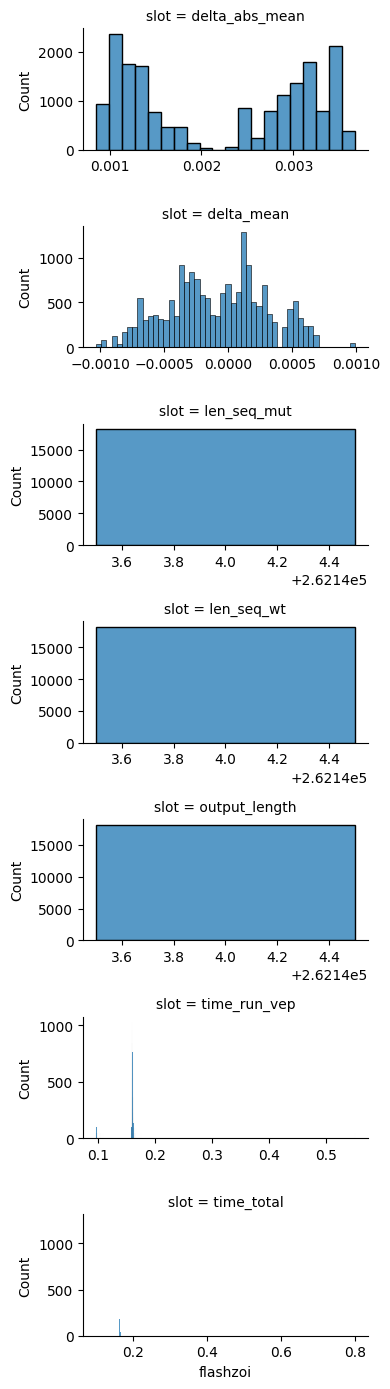

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots for each slot
g = sns.FacetGrid(vep_df.sort_values("slot"),
                  row="slot", 
                  height=2, aspect=2, 
                  sharex=False, 
                  sharey=False)
g.map_dataframe(sns.histplot, x="flashzoi")
plt.tight_layout()

## Run VEP pipeline for full 1KG dataset

Here we extend the `vep_pipeline` to run on all 2.5K+ individuals in the low-coverage WGS cohort.

In [110]:
import src.onekg as og
cohort = "1000_Genomes_on_GRCh38"

# Chrom-specific fasta references: 
# https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz

# Merged fasta reference
# https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
reference = pooch.retrieve(
    url=og.get_ftp_dict()[cohort]['ref'],
    known_hash=None,
    progressbar=True
)

manifest = og.list_remote_vcf(key=cohort)
chroms = manifest['chrom'].unique().tolist()
chroms.reverse()

sites = pl.read_parquet("./data/UTR/clinvar_utr_snv.parquet")
variant_set = "clinvar_utr_snv"
sites

CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,Effect
str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""1""",1013541,"""1185394""","""T""","""C""",""".""",""".""","""AF_ESP=0.88579;AF_TGP=0.90315;…","""0.88579""",null,"""0.90315""","""1175251""","""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""","""15842""","""5_prime_UTR_variant"""
"""1""",1055000,"""263157""","""C""","""T""",""".""",""".""","""AF_ESP=0.34176;AF_EXAC=0.33342…","""0.34176""","""0.33342""","""0.34345""","""249353""","""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""3121561""","""3_prime_UTR_variant"""
"""1""",1055037,"""1292868""","""T""","""C""",""".""",""".""","""AF_TGP=0.38399;ALLELEID=128267…",null,null,"""0.38399""","""1282674""","""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""2465136""","""3_prime_UTR_variant"""
"""1""",1055137,"""1185529""","""C""","""T""",""".""",""".""","""AF_TGP=0.91793;ALLELEID=117525…",null,null,"""0.91793""","""1175253""","""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""2710872""","""3_prime_UTR_variant"""
"""1""",1055153,"""1293006""","""G""","""A""",""".""",""".""","""AF_TGP=0.12181;ALLELEID=128281…",null,null,"""0.12181""","""1282812""","""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""4308920""","""3_prime_UTR_variant"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""X""",154835925,"""368105""","""C""","""T""",""".""",""".""","""AF_TGP=0.55603;ALLELEID=339078…",null,null,"""0.55603""","""339078""","""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Hereditary_factor…","""NC_000023.11:g.154835925C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""F8:2157""","""SO:0001624|3_prime_UTR_variant""","""1""","""1050705""","""3_prime_UTR_variant"""
"""X""",154836383,"""368107""","""C""","""T""",""".""",""".""","""AF_TGP=0.00503;ALLELEID=352804…",null,null,"""0.00503""","""352804""","""MONDO:MONDO:0010602,MedGen:C00…","""Hereditary_factor_VIII_deficie…","""NC_000023.11:g.154836383C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""F8:2157""","""SO:0001624|3_prime_UTR_variant""","""1""","""34700571""","""3_prime_UTR_variant"""
"""X""",154837568,"""368114""","""G""","""A""",""".""",""".""","""AF_ESP=0.01592;AF_EXAC=0.00689…","""0.01592""","""0.00689""","""0.01272""","""352166""","""MONDO:MONDO:0010602,MedGen:C00…","""Hereditary_factor_VIII_deficie…","""NC_000023.11:g.154837568G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""F8:2157""","""SO:0001624|3_prime_UTR_variant""","""1""","""5986887""","""3_prime_UTR_variant"""


In [114]:
import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")


all_models = ["flashzoi", "evo2-7b", "spliceai_mm"]
window_len = 2**18

# Iterate over chromosomes
for chrom in tqdm(chroms[1:2],
                  desc="Iterating over chromosomes"):
    
    # Download VCF files
    vcf_paths = og.download_vcfs(manifest=manifest.loc[manifest['chrom']==chrom,:])
    
    # Create GVL database name
    ds_path = TemporaryDirectory(suffix=f"_{chrom}.gvl").name

    # Create GVL database
    if not os.path.exists(ds_path):
        gvl.write(
            path=ds_path,
            bed=gvl.with_length(bed, window_len),
            variants=variants,
            overwrite=True,
        )
    # Import GVL database
    ds = (
        gvl.Dataset.open(ds_path, reference=reference)
        .with_seqs("haplotypes")
        .with_len(window_len)
    )

    # Import sites_ds
    sites_chrom = sites.filter(pl.col("CHROM").str.replace("chr", "") == chrom.replace("chr", ""))
    site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
    # Add the site_name column
    GVL.add_site_name(site_ds)

    # Create path for results file
    results_dir = os.path.join(os.path.expanduser('~'), 
                               "projects","data")
    
    zarr_path = os.path.join(results_dir,
                             cohort,
                             variant_set,
                             f"{chrom}.zarr") 
    
    # Run VEP pipeline
    ds_results = vp.vep_pipeline(site_ds=site_ds, 
                            zarr_path=zarr_path,
                            all_models=all_models, 
                            checkpoint_frequency="site",
                            
                            verbose=True,
                            force=False,
                               sample_limit=20,
                            site_limit=2
                            )


/home/schilder/.conda/envs/flashzoi/lib/python3.12/tempfile.py:940: ResourceWarning: Implicitly cleaning up <TemporaryDirectory '/tmp/tmp3fcswp_q_chr22.gvl'>
  _warnings.warn(warn_message, ResourceWarning)
2025-05-19 14:33:53.608 | INFO     | genvarloader._dataset._write:write:76 - Writing dataset to /tmp/tmp3fcswp_q_chr22.gvl
2025-05-19 14:33:53.613 | INFO     | genoray._pgen:_read_index:1077 - Loading genoray index.
2025-05-19 14:33:53.971 | INFO     | genvarloader._dataset._write:write:148 - Using 451 samples.
2025-05-19 14:33:53.971 | INFO     | genvarloader._dataset._write:write:154 - Writing genotypes.


  0%|          | 0/20 [00:00<?, ? region/s]

2025-05-19 14:33:55.239 | INFO     | genvarloader._dataset._write:write:178 - Finished writing.
2025-05-19 14:33:55.241 | INFO     | genvarloader._dataset._impl:open:206 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-19 14:33:55.259 | INFO     | genvarloader._dataset._reconstruct:from_path:204 - Loading variant data.
2025-05-19 14:33:55.279 | INFO     | genvarloader._dataset._impl:open:293 - Opened dataset:
GVL store at /tmp/tmp3fcswp_q_chr22.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



Loading existing results from /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


...

Iterating over sites:   0%|          | 0/940 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/451 [00:00<?, ?it/s]

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs

Iterating over samples:   0%|          | 0/451 [00:00<?, ?it/s]

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs

## Get the unique haplotypes

In [ ]:
import awkward as ak
import numba as nb
import numpy as np
from attrs import define
from seqpro._ragged import Ragged
from genvarloader._dataset._reconstruct import Haps, V_IDX_TYPE
from genvarloader._dataset._impl import Dataset


@define
class UniqueInfo:
    """Class to store unique genotypes."""

    # sample, ploidy => ds[region_idx, sample_idx][ploid_idx] (ploidy length) => unique haplotype sequence
    first_idxs: Ragged[np.void]
    """First haplotype indices. Shape: (n_regions, ~n_unique)"""
    inverse_idxs: ak.Array  # total elements = regions * samples * ploidy
    """Inverse indices. Shape: (n_regions, ~n_unique, ~n_haps)"""
    counts: Ragged[np.uint32]
    """Counts. Shape: (n_regions, ~n_unique)"""

    @property
    def n_regions(self) -> int:
        """Number of regions."""
        return self.first_idxs.shape[0]

    @property
    def n_unique(self):
        """Number of unique genotypes."""
        return self.first_idxs.lengths


def unique(dataset: Dataset) -> UniqueInfo:
    if not isinstance(dataset._seqs, Haps):
        raise ValueError(
            "Dataset must have genotypes/haplotypes to compute unique haplotype information."
        )

    genos = dataset._seqs.genotypes
    regions = dataset._full_regions
    out_len = dataset.output_length
    first_idxs, inverse_idxs, counts = _unique_genotypes(
        genos.data, genos.offsets, regions, out_len
    )


@nb.njit(nogil=True, cache=True)
def _unique_genotypes(v_idxs, v_offsets, regions, out_len): 
    pass